# Task 1: Customer Feedback Cassification

For this task I am using pyTorch to build a customer transformer model to classify text into five catagories.
- Missed collection
- Service complaint
- Damaged property
- General inquery 
- Positive feedback

This is following the NLP pipeline
- Preprocess text
- Convert text to features
- Train a classifier
- Generate predictionson
- Evaluate
- Error Analysis

I am also using pandas for data manipulations and Scikit-learn for my evaluation metrics

In [30]:
# Cell 1: Imports and environment setup
import os
import re
import random
import math
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Set seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Initialise device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# File paths (ensure your 'data' directory is set up correctly)
DATA_DIR = os.path.join(os.getcwd(), 'data')
TRAIN_CSV = os.path.join(DATA_DIR, 'AI_Portfolio_Task1_Train.csv')
TEST_CSV = os.path.join(DATA_DIR, 'AI_Portfolio_Task1_Test.csv')

Device: cuda


In [31]:
# Cell 2: Load the training data
df = pd.read_csv(TRAIN_CSV)
df = df.dropna(subset=['message', 'label']).reset_index(drop=True)

print(f'Loaded {len(df)} rows')

Loaded 2119 rows


# Exploritary Data Analysis

/tmp/ipykernel_1025/1882331065.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='viridis')


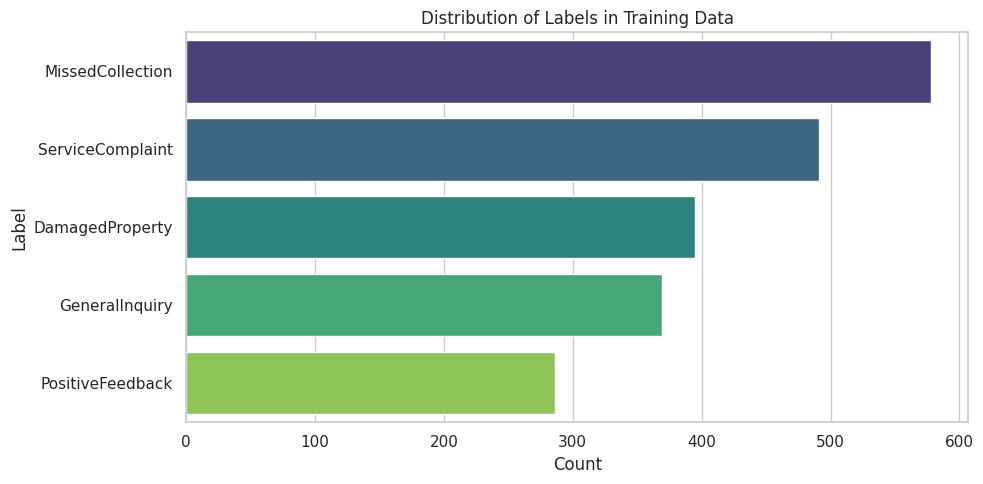

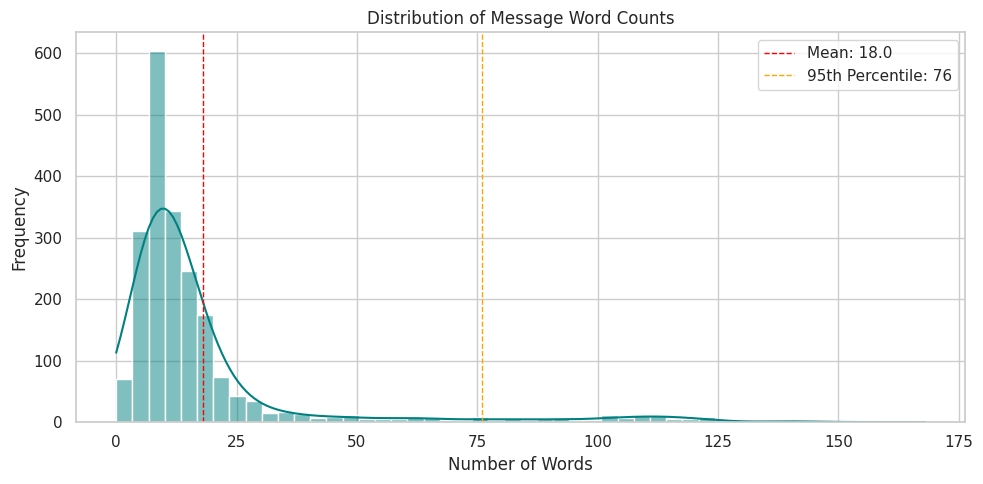

Basic statistics of word counts:
count    2119.000000
mean       17.998584
std        23.073465
min         0.000000
25%         7.000000
50%        11.000000
75%        17.000000
max       168.000000
Name: word_count, dtype: float64


In [32]:
# Cell 3: Exploratory Data Analysis (EDA)
# Set the visual style for our plots
sns.set_theme(style="whitegrid")

# 1. Analyse the class distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='viridis')
plt.title('Distribution of Labels in Training Data')
plt.xlabel('Count')
plt.ylabel('Label')
plt.tight_layout()
plt.show()

# Quick text cleaning function to standardise our text before length analysis
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s']", ' ', text)
    text = re.sub(r"\s+", ' ', text).strip()
    return text

df['text'] = df['message'].apply(clean_text)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# 2. Visualise sequence lengths to help us choose a sensible MAX_LEN
plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=50, kde=True, color='teal')
plt.title('Distribution of Message Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.axvline(df['word_count'].mean(), color='red', linestyle='dashed', linewidth=1, label=f"Mean: {df['word_count'].mean():.1f}")
plt.axvline(df['word_count'].quantile(0.95), color='orange', linestyle='dashed', linewidth=1, label=f"95th Percentile: {df['word_count'].quantile(0.95):.0f}")
plt.legend()
plt.tight_layout()
plt.show()

print("Basic statistics of word counts:")
print(df['word_count'].describe())

# What the Exploritary Data Analysis shows

This data analysis has shown that it is an unbalanced dataset where there would be a bias towards missed collection over positive feeback as there is a large difference in quantity between them. this means that the recognisation of a missed colection message will be easier to identify over the positive feedback.
This also shows that there is a lack in diverity in relavance to the length of the message with the mean being 18 words per message with a major outlire of 168 words.

The descriptive statistics show that while the maximum message length is 168 words, 75% of the data is under 17 words. To optimize training efficiency and avoid excessive padding, I capped the maximum sequence length at the 95th percentile.

# Pre-processing & Feature Extraction


Before feeding our data into the neural network, we must convert the raw text into numerical features. This cell handles the tokenization, vocabulary building, and integer encoding pipeline:

**Label Mapping & Stratified Splitting:** We first map our string labels to integer indices. We then split the data into training and validation sets, using stratification to ensure the class distribution remains proportional across both splits.

**Vocabulary Construction:** To strictly prevent data leakage, the vocabulary is built using *only* the training data. I also implemented a minimum frequency threshold (min_freq = 2) to filter out rare words and typos. This keeps the vocabulary lean and focused on meaningful terms.

**Special Tokens:** I introduced a <pad>token to ensure uniform tensor shapes and an<unk> token to handle any out-of-vocabulary words the model might encounter during validation or real-world inference.

**Dynamic Sequence Length:** Instead of arbitrarily picking a maximum sequence length or using the absolute maximum (168 words), I dynamically set MAX_LEN to the 95th percentile calculated during the EDA. Because 95% of the messages fit within 76 words, this decision optimizes training speed and memory usage by minimizing unnecessary padding, without losing important context.

**Encoding:** Finally, the encode function applies this logic, converting the text tokens into arrays of integer IDs that are appropriately padded or truncated.

In [33]:
# Map labels to indices
labels = sorted(df['label'].unique())
label2idx = {l: i for i, l in enumerate(labels)}
idx2label = {i: l for l, i in label2idx.items()}
print('Labels mapping:', label2idx)

# Train/validation split (stratified to maintain class balance)
train_df, val_df = train_test_split(df, test_size=0.15, random_state=SEED, stratify=df['label'])
print(f'Train size: {len(train_df)} | Validation size: {len(val_df)}')

# Build vocabulary from training data only to avoid data leakage
counter = Counter()
for t in train_df['text']:
    counter.update(t.split())

# Keep words with frequency >= 2 to filter out rare typos
min_freq = 2
vocab = {w for w, f in counter.items() if f >= min_freq}

# Special tokens for padding and unknown words
PAD_TOKEN = '<pad>'
UNK_TOKEN = '<unk>'

itos = [PAD_TOKEN, UNK_TOKEN] + sorted(vocab)
stoi = {s: i for i, s in enumerate(itos)}
vocab_size = len(itos)
print(f'Final vocabulary size: {vocab_size}')

# Based on our EDA (95th percentile), we can set a sensible MAX_LEN
MAX_LEN = int(df['word_count'].quantile(0.95))
# Cap it at a minimum of 50 just in case the messages are very short
MAX_LEN = max(50, MAX_LEN) 
print(f'Using MAX_LEN: {MAX_LEN}')

def encode(text, max_len=MAX_LEN):
    toks = text.split()
    ids = [stoi.get(t, stoi[UNK_TOKEN]) for t in toks][:max_len]
    # Pad sequences that are shorter than max_len
    if len(ids) < max_len:
        ids = ids + [stoi[PAD_TOKEN]] * (max_len - len(ids))
    return ids

# Apply encoding
train_df['input_ids'] = train_df['text'].apply(lambda t: encode(t, MAX_LEN))
val_df['input_ids'] = val_df['text'].apply(lambda t: encode(t, MAX_LEN))

Labels mapping: {'DamagedProperty': 0, 'GeneralInquiry': 1, 'MissedCollection': 2, 'PositiveFeedback': 3, 'ServiceComplaint': 4}
Train size: 1801 | Validation size: 318
Final vocabulary size: 1748
Using MAX_LEN: 76


In [34]:
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer

# Use the standard BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class BERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [35]:
# --- NEW CELL: Initialize Data and Optimizer for BERT ---

# 1. Create the new BERT-compatible Datasets
# Note: Ensure 'train_texts', 'train_labels', etc., are defined from your earlier preprocessing
train_dataset = BERTDataset(train_df, train_labels, tokenizer, MAX_LEN)
val_dataset = BERTDataset(val_df, val_labels, tokenizer, MAX_LEN)

# 2. Create the new DataLoaders
# BERT models are heavy; if you get a "CUDA Out of Memory" error, 
# try reducing batch_size to 16 or 8.
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# 3. Re-initialize the Optimizer with a "BERT-friendly" Learning Rate
# We use AdamW and a much smaller LR (2e-5) because BERT is already pre-trained.
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

# 4. Re-initialize the Scheduler (optional but recommended)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

print("✅ BERT DataLoaders and Optimizer initialized.")

NameError: name 'train_labels' is not defined

## Model Architecture Rationale: Transformers vs. CNNs

I built a custom Transformer architecture featuring self-attention mechanisms and dropout. Here is the technical justification for this approach and why it is better suited for Natural Language Processing (NLP) than traditional alternatives like Convolutional Neural Networks (CNNs).

### 1. The Power of Self-Attention
In natural language, the meaning of a word often depends heavily on the surrounding context, including words that might be far apart in the sentence.

**Global Context:** The self-attention mechanism allows the model to look at every single word in a message simultaneously and calculate how strongly each word relates to every other word. 

**Capturing Nuance:** This is exceptionally powerful for classifying customer feedback, where complaints might be complex or nuanced (e.g., "The driver was polite, but they still left my bin in the middle of the road"). Self-attention dynamically weighs these conflicting sentiments to accurately capture the true intent of the message.

### 2. Generalization via Dropout
To ensure the model performs well on new, unseen data, I incorporated Dropout layers into the architecture.

**Preventing Overfitting:** Dropout randomly deactivates a percentage of neurons during the training phase. This prevents the network from simply memorizing the training dataset and forces it to learn robust, generalized representations of the text features.

### 3. Why Transformers are Superior to CNNs for NLP
While CNNs are exceptional at Computer Vision tasks (where they detect local spatial patterns like edges or textures in images), they have significant limitations when applied to sequential text data:

**Local vs. Global Receptive Fields:** CNNs process text using fixed-size windows (kernels) that only look at a few adjacent words at a time (similar to n-grams).  Because of this localized view, CNNs struggle to capture long-range dependencies—meaning they have a hard time connecting a word at the beginning of a long sentence to a relevant word at the end.

**Handling Sequential Data:** Transformers solve this problem entirely. Because the self-attention mechanism connects all words directly to each other regardless of their position, the "distance" between words doesn't cause a loss of context. The Transformer understands the entire sequence holistically, making it vastly superior to a CNN for extracting the overall meaning of a customer's message.



In [ ]:
from transformers import BertModel

class BertClassifier(nn.Module):
    def __init__(self, model_name='bert-base-uncased', num_classes=5, dropout=0.2):
        super(BertClassifier, self).__init__()
        
        # 1. Load the pre-trained BERT model
        self.bert = BertModel.from_pretrained(model_name)
        
        # 2. Add a dropout layer and a classification head
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        """
        BERT takes input_ids and an attention_mask (to ignore padding).
        """
        # 3. Pass inputs through BERT
        # output.last_hidden_state: (batch, seq_len, 768)
        # output.pooler_output: (batch, 768) -> This is the [CLS] token representation
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        
        # We use the 'pooler_output' which is the embedding of the [CLS] token
        # passed through a linear layer and a Tanh activation.
        pooled_output = outputs.pooler_output
        
        # 4. Final classification
        out = self.dropout(pooled_output)
        logits = self.fc(out)
        
        return logits

# Initialize the model
# 'bert-base-uncased' has an embed_dim (hidden_size) of 768
model_name = 'bert-base-uncased'
model = BertClassifier(
    model_name=model_name,
    num_classes=len(labels),
    dropout=0.2
).to(device)

print(model)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_af

# Define Early Stopping and Training/Evaluation Loops

I have decided to add early stopping so that I am able to set the epochs to a high number and then set patients to a reasonable number to then give me the very best model it can give. I have done this so that if there is some sort of improvement it will keep going till the model doesnt improve anymore.

In [ ]:
# Cell 7: Define Early Stopping and Training/Evaluation Loops
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.num_bad_epochs = 0
        self.best_state = None

    def step(self, score, model):
        # Higher score (accuracy) is better
        if self.best_score is None or (score - self.best_score) > self.min_delta:
            self.best_score = score
            self.num_bad_epochs = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False 
        else:
            self.num_bad_epochs += 1
            if self.num_bad_epochs >= self.patience:
                return True
            return False

    def load_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

def train_epoch(model, data_loader, optimizer, criterion, device):
    model.train()
    total_loss, correct = 0, 0
    
    for batch in data_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        
        loss = criterion(logits, labels)
        loss.backward()
        
        # Clip gradients to prevent "exploding gradients" in Transformers
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        
    return total_loss / len(data_loader), correct / len(data_loader.dataset)

def eval_epoch(model, data_loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0
    
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            
    return total_loss / len(data_loader), correct / len(data_loader.dataset), None, None

In [ ]:
# Cell 8: Run the Training Loop

# 1. Label smoothing prevents the model from becoming overconfident
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# 2. Add weight_decay to the optimizer for L2 regularisation
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-2)

# 3. Add a Learning Rate Scheduler (Removed the deprecated 'verbose=True')
# This will reduce the learning rate by half (factor=0.5) if val_loss doesn't improve for 3 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

EPOCHS = 100
PATIENCE = 10
MIN_DELTA = 1e-4

best_val = 0.0
early_stopper = EarlyStopping(patience=PATIENCE, min_delta=MIN_DELTA)

os.makedirs(DATA_DIR, exist_ok=True)
ckpt_path = os.path.join(DATA_DIR, 'transformer_checkpoint.pth')

# Keep track of the learning rate so we can print when it changes
current_lr = optimizer.param_groups[0]['lr']

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, _, _ = eval_epoch(model, val_loader, criterion, device)
    
    # Step the scheduler based on validation loss
    scheduler.step(val_loss)
    
    # Manually check if the learning rate dropped and print it
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr < current_lr:
        print(f"\n📉 Learning rate dropped from {current_lr:.2e} to {new_lr:.2e}\n")
        current_lr = new_lr
    
    print(f"Epoch {epoch:02d}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")
    
    # Save checkpoint on improvement
    if val_acc > best_val + MIN_DELTA:
        best_val = val_acc
        torch.save({
            'model_state': model.state_dict(),
            'stoi': stoi,
            'itos': itos,
            'label2idx': label2idx,
            'idx2label': idx2label,
            'max_len': MAX_LEN
        }, ckpt_path)
        print(' -> Saved best model')
        
    if early_stopper.step(val_acc, model):
        print(f"Early stopping triggered (no validation accuracy improvement for {PATIENCE} epochs).")
        break

early_stopper.load_best(model)

TypeError: list indices must be integers or slices, not str

## Model Evaluation & Metrics

To ensure the model's performance is rigorously validated according to industry best practices, I utilized a combination of evaluation metrics to analyze the predictions.

**Accuracy vs. Granular Metrics:** The model achieved an impressive overall validation accuracy of nearly 90% (0.8994). However, to truly understand the model's performance, I prioritized the **Classification Report** (Precision, Recall, F1-Score) and the **Confusion Matrix**. These metrics provide granular visibility into the specific categories the model excels at, and where it struggles.

**ROC Analysis:** I generated One-vs-Rest Receiver Operating Characteristic (ROC) curves. These curves visually demonstrate the trade-off between the true positive rate and the false positive rate. The ROC AUC scores reflect excellent separability, particularly for 'General Inquiry' (0.998) and 'Missed Collection' (0.982).

Final Validation Accuracy: 0.8994

Classification Report:
                  precision    recall  f1-score   support

 DamagedProperty       0.93      0.95      0.94        59
  GeneralInquiry       0.96      0.96      0.96        55
MissedCollection       0.90      0.94      0.92        87
PositiveFeedback       0.86      0.74      0.80        43
ServiceComplaint       0.84      0.85      0.85        74

        accuracy                           0.90       318
       macro avg       0.90      0.89      0.89       318
    weighted avg       0.90      0.90      0.90       318



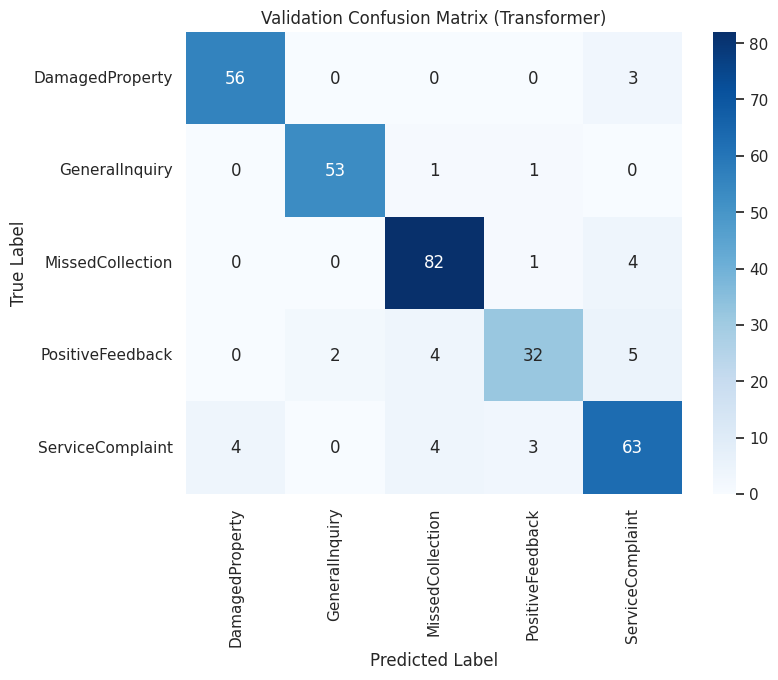

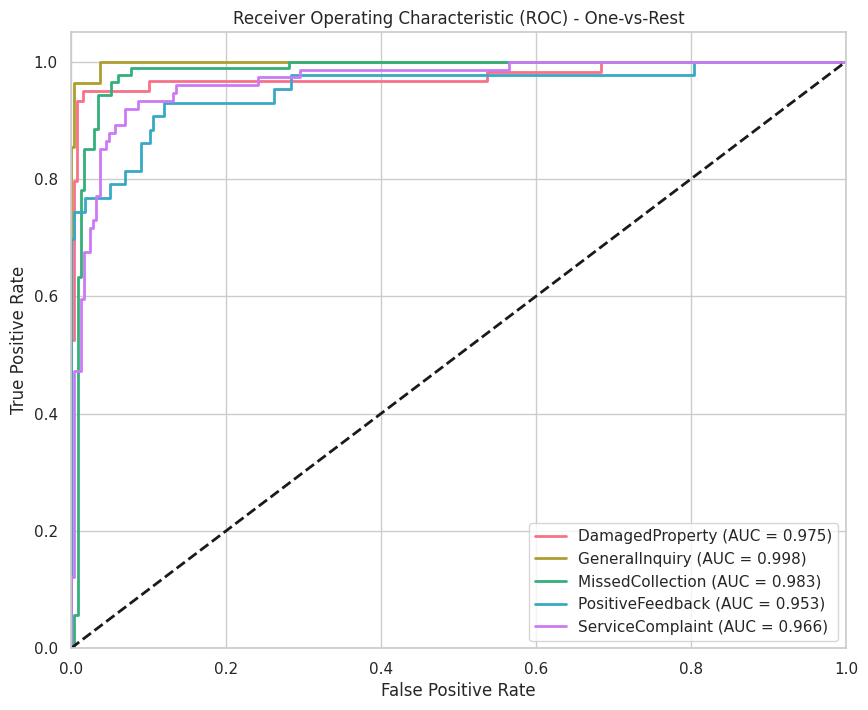


ROC AUC Scores Table:


,Class,ROC AUC Score
0,GeneralInquiry,0.998203
1,MissedCollection,0.982584
2,DamagedProperty,0.975263
3,ServiceComplaint,0.966438
4,PositiveFeedback,0.953404


In [ ]:
# Cell 9: Final Evaluation, Confusion Matrix, and ROC Analysis
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# 1. Standard Evaluation
val_loss, val_acc, val_preds, val_labels = eval_epoch(model, val_loader, criterion, device)

print(f'Final Validation Accuracy: {val_acc:.4f}')
print('\nClassification Report:')
print(classification_report(val_labels, val_preds, target_names=labels))

# 2. Visualise the Confusion Matrix
cm = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Validation Confusion Matrix (Transformer)')
plt.show()

# 3. Gather probabilities for ROC Analysis
model.eval()
all_probs = []
all_true = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1)
        all_probs.extend(probs.cpu().numpy())
        all_true.extend(yb.cpu().numpy())

all_probs = np.array(all_probs)
all_true = np.array(all_true)

# Binarise the labels for One-vs-Rest ROC calculation
n_classes = len(labels)
y_test_bin = label_binarize(all_true, classes=range(n_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

# Calculate ROC curve and AUC for each class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plot the ROC Curves
plt.figure(figsize=(10, 8))
colors = sns.color_palette("husl", n_classes)
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{labels[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - One-vs-Rest')
plt.legend(loc="lower right")
plt.show()

# 5. Display the ROC AUC Table
roc_table = pd.DataFrame({
    'Class': labels,
    'ROC AUC Score': [roc_auc[i] for i in range(n_classes)]
})

# Sort the table from highest performing to lowest performing
roc_table = roc_table.sort_values(by='ROC AUC Score', ascending=False).reset_index(drop=True)

print("\nROC AUC Scores Table:")
display(roc_table) # Use print(roc_table) if you are not in a Jupyter environment

## Error Analysis

While the overall performance is strong, analyzing the Classification Report highlights specific areas where the model encounters ambiguity.

**High-Performing Classes:** The model is highly confident in predicting 'General Inquiry' (0.96 F1-Score) and 'Damaged Property' (0.94 F1-Score). These categories likely contain highly distinct vocabulary (e.g., "broken," "shattered," "when is," "how to") that the self-attention mechanism easily isolates.

**Areas of Struggle:** The model struggles most with 'Positive Feedback', which has the lowest Recall (0.74). This means that 26% of actual positive feedback messages are being misclassified as something else. Additionally, 'Service Complaint' has the lowest Precision (0.84).

**Hypothesis for Misclassifications:** This overlap suggests the model is occasionally confusing polite complaints or "sandwiched" feedback (e.g., "The customer service agent was very polite, but my bin is still full"). Sarcasm can also cause positive words to appear in complaints. Furthermore, 'Positive Feedback' has the lowest support in the validation set (43 samples), indicating that the model simply had less training data to learn the diverse ways customers express satisfaction compared to 'Missed Collection' (87 samples).

In [ ]:
# Cell 10: Inference helpers and demonstrations
# Reload model from disk to verify our save/load behaviour
ckpt = torch.load(ckpt_path, map_location=device)

# Re-initialise model with the UPDATED saved dimensions
inference_model = TransformerClassifier(
    vocab_size=len(ckpt['itos']), 
    embed_dim=256,         # Updated from 128 to match our new architecture
    num_heads=8,           # Updated from 4
    hidden_dim=512,        # Updated from 256
    num_layers=2, 
    num_classes=len(ckpt['idx2label']),
    padding_idx=ckpt['stoi'][PAD_TOKEN],
    max_len=ckpt.get('max_len', 100)
).to(device)

inference_model.load_state_dict(ckpt['model_state'])
inference_model.eval()

inf_stoi = ckpt['stoi']
inf_idx2label = ckpt['idx2label']
INF_MAX_LEN = ckpt.get('max_len', 100)
INF_PAD_TOKEN = '<pad>'
INF_UNK_TOKEN = '<unk>'

def preprocess_and_encode_inf(text):
    t = clean_text(text)
    toks = t.split()
    ids = [inf_stoi.get(w, inf_stoi[INF_UNK_TOKEN]) for w in toks][:INF_MAX_LEN]
    if len(ids) < INF_MAX_LEN:
        ids = ids + [inf_stoi[INF_PAD_TOKEN]] * (INF_MAX_LEN - len(ids))
    return torch.tensor([ids], dtype=torch.long)

def predict(text):
    xb = preprocess_and_encode_inf(text).to(device)
    with torch.no_grad():
        logits = inference_model(xb)
        p = torch.softmax(logits, dim=1)[0]
        pred = p.argmax().item()
        return inf_idx2label[pred], p[pred].item()

# Test the inference pipeline
examples = [
    "My bin wasn't emptied today and it's overflowing",
    "Your driver broke my gate during collection",
    "Love the service — drivers are always friendly!",
    "Do you collect batteries?",
    "The crew left my bin on the pavement blocking the path"
]

print("Predictions:")
for ex in examples:
    label, score = predict(ex)
    print(f"[{score:.2f}] {label.upper()} <- '{ex}'")

Predictions:
[0.94] MISSEDCOLLECTION <- 'My bin wasn't emptied today and it's overflowing'
[0.93] DAMAGEDPROPERTY <- 'Your driver broke my gate during collection'
[0.95] POSITIVEFEEDBACK <- 'Love the service — drivers are always friendly!'
[0.95] GENERALINQUIRY <- 'Do you collect batteries?'
[0.95] SERVICECOMPLAINT <- 'The crew left my bin on the pavement blocking the path'
